In [1]:
library(ggplot2)
library(tidyverse)
library(ggrepel)
library(readr)

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.5.1
✔ lubridate 1.9.3     ✔ tibble    3.2.1
✔ purrr     1.0.2     ✔ tidyr     1.3.1
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors


In [2]:
tcga_color_map <- read_csv("../../data/RNA_Celligner/TCGA_ColorPalette.csv")
tissue_type_map <- tcga_color_map$`Hex Colors`
names(tissue_type_map) <-  tcga_color_map$`Study Abbreviation`


Rows: 41 Columns: 3
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (3): Hex Colors, Study Abbreviation, Study Name

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


In [3]:
umap_df<-read.csv("../../data/RNA_Celligner/Umap_table_Extended_data_5D.csv",row.names = 1 )


In [4]:
umap_df$cell_type <- factor(
  umap_df$cell_type, 
  levels = c("TCGA Tumor", "HCMI Tumor", "HCMI Model")
)

# Reorder data so TCGA is drawn first, then HCMI Tumor, then HCMI Model
umap_df <- umap_df[order(umap_df$cell_type), ]


shape_map = c('TCGA Tumor'=22,
              'HCMI Tumor'=24,
              'HCMI Model'=21) 

alpha_map = c('TCGA Tumor'=0.2,
              'HCMI Tumor'=0.70,
              'HCMI Model'=0.70)
color_map_border = c('TCGA Tumor'="NA",
                     'HCMI Tumor'="black",
                     'HCMI Model'="black")

umap_plot<- ggplot(umap_df, aes(x = umap1, y = umap2, 
                                 fill = Diagnosis_TCGA_HCMI_Code, 
                                 color = cell_type, 
                                 alpha = cell_type, 
                                 shape = cell_type
                             )) +  
  geom_point(size = 2, stroke = 0.3) +
  theme_minimal() +
 # coord_equal() + #xlim = x_lim, ylim = y_lim
  scale_shape_manual(values = shape_map) +
  scale_color_manual(values = color_map_border) +
  scale_fill_manual(values = tissue_type_map) +
  scale_alpha_manual(values = alpha_map) +
  labs(x = "UMAP1", y = "UMAP2") +
  theme(
    axis.text.x = element_blank(),
    axis.text.y = element_blank(),
    axis.ticks = element_blank(),
    axis.title.x = element_text(size = 12),
    axis.title.y = element_text(size = 12),
    panel.grid.major = element_blank(),
    panel.grid.minor = element_blank(),
    panel.background = element_rect(fill = 'white', colour = 'black'),
    legend.position = "right"
  )+
  guides(fill = "none", color = "none") +
  labs(title = 'Celligner RNA UMAP')

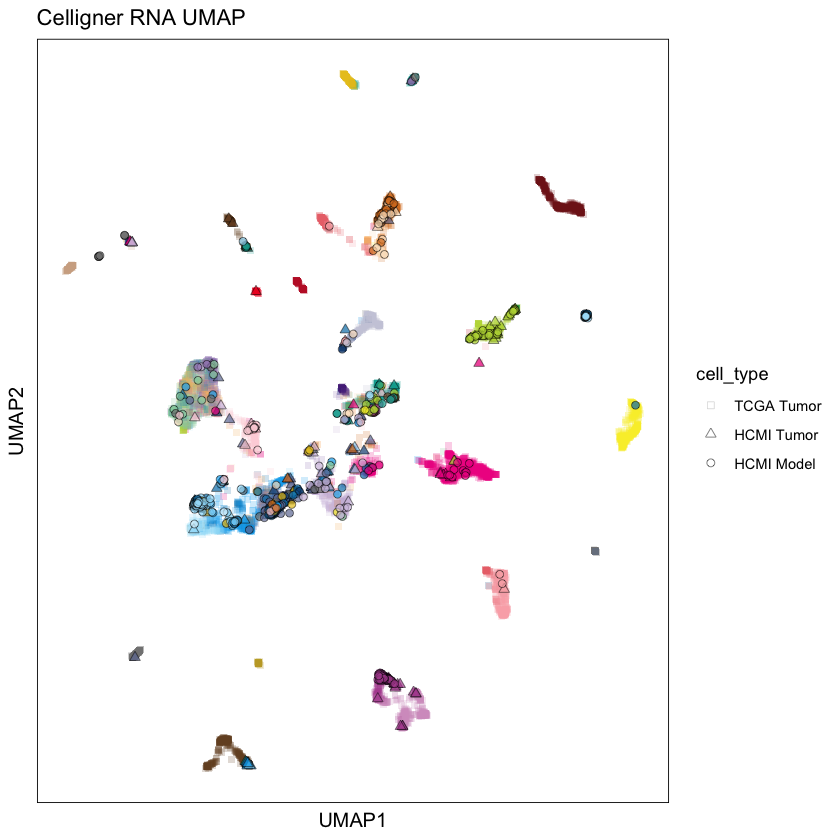

In [5]:
umap_plot